# 04 · Sensitivity sweeps (the paper's figures)

Using the **real HVAC jobs**, we sweep the four things a reviewer will ask about:

- **(a) flexibility** — savings vs `flex_hours` (how much slack we grant HVAC).
- **(b) capacity** — savings vs a per-hour power cap $M$ (a shared-transformer limit).
- **(c) season** — savings by month (winter heating vs summer cooling).
- **(d) emission factors** — savings vs the `OTH` factor (an explicit modeling choice).

In [1]:
# --- standard setup for every notebook in this paper ------------------------
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, "..")                 # find cals (in ../)
from dotenv import load_dotenv; load_dotenv("../.env")  # loads EIA_API_KEY if present
from cals import *          # FACTORS, carbon_intensity, Job, schedule, fifo_baseline, ...
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import nb_utils as U             # guarded data loaders + figure helper (see notebooks/nb_utils.py)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
ci, source = U.get_carbon_intensity()
mix, _ = U.get_fuel_mix()                      # needed for the factor sweep (d)
print("carbon source:", source)
hvac_jobs, run_hours, hvac_df = U.load_hvac_jobs(flex_hours=6)
fifo0 = fifo_baseline(hvac_jobs, ci)["total_gco2"]
print("HVAC jobs:", len(hvac_jobs))

carbon source: EIA ISO-NE (LIVE API)


HVAC jobs: 8363


## (a) Savings vs flexibility (`flex_hours`)

More slack = more cheap hours reachable = more savings, with diminishing returns once the
window already spans the daily CI trough. We rebuild the jobs at each `flex_hours` (it
changes both the window **and** the job set), then compare fifo vs optimal.

saved figure -> /project/painting/local-projects-to-run/carbon-aware-load-scheduling/code/figures/04a_savings_vs_flex.png


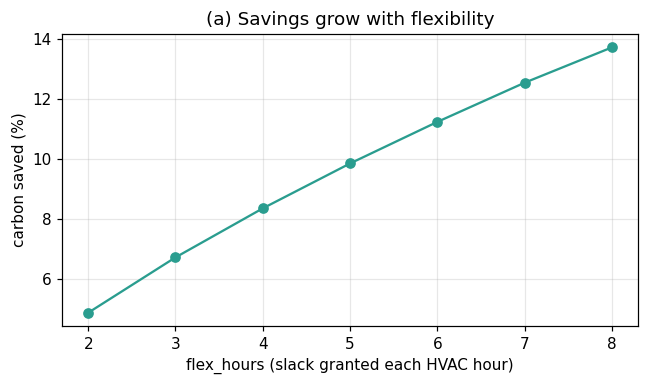

In [3]:
flex_vals = list(range(2, 9))
sav_flex = []
for f in flex_vals:
    jobs, _ = nrel_to_jobs(hvac_df, utc_offset_hours=-5, flex_hours=f)
    fb = fifo_baseline(jobs, ci)["total_gco2"]
    op = schedule(jobs, ci)["total_gco2"]
    sav_flex.append(U.savings_pct(fb, op))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(flex_vals, sav_flex, "o-", color="#2a9d8f")
ax.set_xlabel("flex_hours (slack granted each HVAC hour)"); ax.set_ylabel("carbon saved (%)")
ax.set_title("(a) Savings grow with flexibility")
fig.tight_layout(); U.savefig(fig, "04a_savings_vs_flex.png"); plt.show()

## (b) Savings vs a shared capacity cap $M$

A cap limits how much load may pile into the cheapest hours (e.g. a shared transformer).

**Honest accounting.** Under a tight cap some jobs cannot be shifted. If we simply *dropped*
them, the surviving jobs would flatter the ratio (survivorship bias -- fewer, easier jobs).
Instead we charge every un-shiftable job at its **metered run hour** (the physical
do-nothing) via `baseline_hours=run_hours`. Savings are then non-negative **by construction**
and fall smoothly to ~0 as $M \to 0$.

saved figure -> /project/painting/local-projects-to-run/carbon-aware-load-scheduling/code/figures/04b_savings_vs_capacity.png


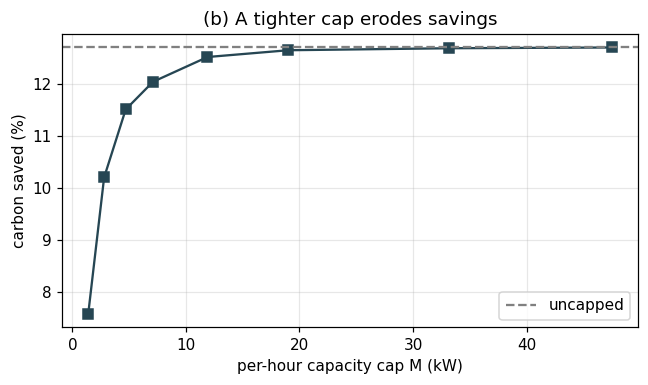

uncapped peak concurrent load: 47.5 kW


In [4]:
# physical do-nothing baseline: every HVAC hour priced where it actually ran
base_run = U.do_nothing_gco2(hvac_jobs, run_hours, ci)

# uncapped optimal placement -> find the peak concurrent shifted load (kW)
opt = schedule(hvac_jobs, ci, baseline_hours=run_hours)
byid = {j.job_id: j for j in hvac_jobs}
load = {}
for jid, st in opt["assignments"].items():
    j = byid[jid]
    for k in range(duration_h(j)):
        hr = st + pd.Timedelta(hours=k); load[hr] = load.get(hr, 0.0) + j.power_kw
peak = max(load.values())

caps = [round(peak * f, 1) for f in (0.03, 0.06, 0.1, 0.15, 0.25, 0.4, 0.7, 1.0)]
sav_cap = []
for M in caps:
    tot = schedule(hvac_jobs, ci, capacity_kw=M, baseline_hours=run_hours)["total_gco2"]
    sav_cap.append(U.savings_pct(base_run, tot))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(caps, sav_cap, "s-", color="#264653")
ax.axhline(U.savings_pct(base_run, opt["total_gco2"]), ls="--", color="gray",
           label="uncapped")
ax.set_xlabel("per-hour capacity cap M (kW)"); ax.set_ylabel("carbon saved (%)")
ax.set_title("(b) A tighter cap erodes savings"); ax.legend()
fig.tight_layout(); U.savefig(fig, "04b_savings_vs_capacity.png"); plt.show()
print("uncapped peak concurrent load: %.1f kW" % peak)

## (c) Seasonal savings (by month)

Bucketing jobs by the month they ran shows *when* the grid offers the most room to shift
(large CI swings + plenty of flexible HVAC load).

saved figure -> /project/painting/local-projects-to-run/carbon-aware-load-scheduling/code/figures/04c_savings_by_month.png


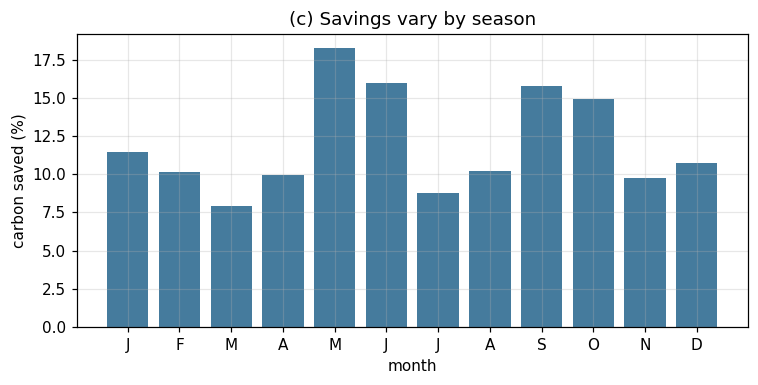

In [5]:
month = np.array([pd.Timestamp(run_hours[j.job_id]).month for j in hvac_jobs])
sav_month = []
for m in range(1, 13):
    jm = [j for j, mm in zip(hvac_jobs, month) if mm == m]
    fb = fifo_baseline(jm, ci)["total_gco2"]
    op = schedule(jm, ci)["total_gco2"]
    sav_month.append(U.savings_pct(fb, op) if fb else 0.0)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(range(1, 13), sav_month, color="#457b9d")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_xlabel("month"); ax.set_ylabel("carbon saved (%)")
ax.set_title("(c) Savings vary by season")
fig.tight_layout(); U.savefig(fig, "04c_savings_by_month.png"); plt.show()

## (d) Emission-factor sensitivity (`OTH`)

`FACTORS['OTH'] = 230` is a **modeling choice** (AR5 biomass median as a proxy for EIA's
blended "other" bucket); a defensible range is ~130–420. We re-price the *same* fuel mix
under each value (`U.ci_from_factors`) and re-schedule. If savings barely move, the headline
result is robust to this choice.

saved figure -> /project/painting/local-projects-to-run/carbon-aware-load-scheduling/code/figures/04d_savings_vs_oth_factor.png


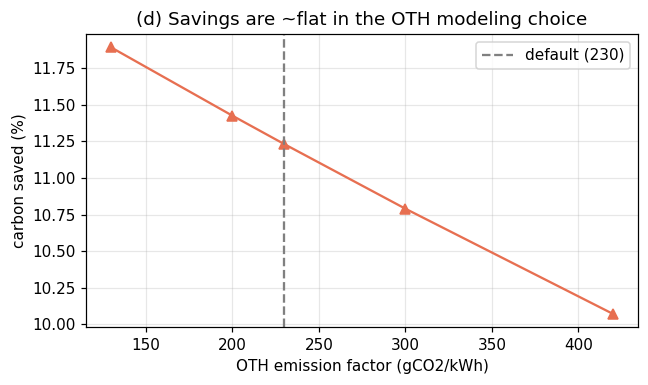

savings range across OTH 130..420: 10.07 .. 11.89 %


In [6]:
oth_vals = [130, 200, 230, 300, 420]
sav_oth = []
for v in oth_vals:
    f = dict(FACTORS); f["OTH"] = v
    ci_v = U.ci_from_factors(mix, f)
    fb = fifo_baseline(hvac_jobs, ci_v)["total_gco2"]
    op = schedule(hvac_jobs, ci_v)["total_gco2"]
    sav_oth.append(U.savings_pct(fb, op))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(oth_vals, sav_oth, "^-", color="#e76f51")
ax.axvline(230, ls="--", color="gray", label="default (230)")
ax.set_xlabel("OTH emission factor (gCO2/kWh)"); ax.set_ylabel("carbon saved (%)")
ax.set_title("(d) Savings are ~flat in the OTH modeling choice"); ax.legend()
fig.tight_layout(); U.savefig(fig, "04d_savings_vs_oth_factor.png"); plt.show()
print("savings range across OTH 130..420: %.2f .. %.2f %%" % (min(sav_oth), max(sav_oth)))

## Robustness across three Massachusetts buildings

Each row uses a real full-year NREL ResStock heat-pump building, the observed HVAC run hour
as its baseline, and real 2019 ISO-NE carbon. The 95% interval resamples complete days,
keeping every HVAC job from a sampled day together.


In [ ]:
if source != "EIA ISO-NE (LIVE API)":
    raise RuntimeError("Real MA robustness results require the EIA ISO-NE carbon signal.")

ma_files = (
    "bldg274807_MA_year.parquet",
    "bldg286081_MA_year.parquet",
    "bldg486202_MA_year.parquet",
)
rows = []
for seed, fname in enumerate(ma_files, start=42):
    jobs, run_hours, _ = U.load_hvac_jobs(fname, flex_hours=6, utc_offset_hours=-5)
    baseline = U.do_nothing_gco2(jobs, run_hours, ci)
    scheduled = schedule(jobs, ci, baseline_hours=run_hours)
    daily = pd.DataFrame({
        "day": [run_hours[job.job_id].normalize() for job in jobs],
        "baseline_gco2": [U.price_at(job, run_hours[job.job_id], ci) for job in jobs],
        "scheduled_gco2": [U.price_at(job, scheduled["assignments"][job.job_id], ci) for job in jobs],
    }).groupby("day", as_index=True).sum()
    ci_lower, ci_upper = U.bootstrap_savings_ci(
        daily["baseline_gco2"], daily["scheduled_gco2"], seed=seed
    )
    rows.append({
        "building": fname.removesuffix("_MA_year.parquet"),
        "jobs": len(jobs),
        "savings %": round(U.savings_pct(baseline, scheduled["total_gco2"]), 2),
        "95% CI lower": round(ci_lower, 2),
        "95% CI upper": round(ci_upper, 2),
    })
ma_robustness = pd.DataFrame(rows).set_index("building")
display(ma_robustness)


## (e) Real Alibaba AI sensitivity sweep

The official Alibaba GPU v2020 task table records completed jobs but no real scheduling
deadline. We therefore keep only `Terminated` tasks and sweep the two explicit assumptions:
per-GPU power and additional deadline flexibility. The trace timestamps are aligned to the
2019 ISO-NE carbon timeline, so this cell fetches the matching real EIA window and raises
instead of falling back to a demo curve.


In [ ]:
import os

ai_csv = U.DATA / "ai" / "pai_task_table.csv"
if not ai_csv.is_file():
    raise FileNotFoundError(f"Missing official Alibaba task table: {ai_csv}")
if not os.environ.get("EIA_API_KEY", "").strip():
    raise RuntimeError("Set EIA_API_KEY in ../.env; real AI results cannot use a demo CI curve.")

gpu_power_vals = (0.3, 0.4, 0.5)
ai_flex_vals = (0, 2, 6, 12, 24)

batch_size = 10_000
completed_tasks = 0
ai_start = ai_end = None
aggregate_parts = []
for ai_raw in iter_pai_task_table(ai_csv, chunksize=batch_size):
    ai_parsed = parse_alibaba_trace(ai_raw, origin=U.DEMO_ORIGIN)
    if ai_parsed.empty:
        continue
    completed_tasks += len(ai_parsed)
    aggregate_parts.append(aggregate_alibaba_tasks(ai_parsed))
    chunk_start = ai_parsed["submit"].min().floor("h")
    chunk_end = (
        ai_parsed["submit"]
        + pd.to_timedelta(ai_parsed["duration_h"], unit="h")
        + pd.Timedelta(hours=max(ai_flex_vals))
    ).max().ceil("h")
    ai_start = chunk_start if ai_start is None else min(ai_start, chunk_start)
    ai_end = chunk_end if ai_end is None else max(ai_end, chunk_end)
if ai_start is None or ai_end is None:
    raise RuntimeError("The Alibaba table contained no completed GPU tasks.")
ai_groups = (
    pd.concat(aggregate_parts, ignore_index=True)
    .groupby(["earliest_start", "duration_h"], as_index=False)
    .agg(task_count=("task_count", "sum"), total_gpus=("total_gpus", "sum"))
)
ai_mix = fetch_eia_fuel_mix(
    ai_start.date(),
    ai_end.date(),
    "ISO-NE",
    raw_dir=U.DATA / "carbon",
    api_key=os.environ["EIA_API_KEY"],
    use_synthetic_if_missing=False,
)
ai_ci = carbon_intensity(ai_mix)
if ai_ci.empty:
    raise RuntimeError("EIA returned no carbon-intensity values for the Alibaba window.")

rows = []
for gpu_power_kw in gpu_power_vals:
    for flex_hours in ai_flex_vals:
        costs = uncapped_alibaba_costs(
            ai_groups,
            ai_ci,
            gpu_power_kw=gpu_power_kw,
            flex_hours=flex_hours,
        )
        baseline_gco2 = costs["baseline_gco2"]
        scheduled_gco2 = costs["scheduled_gco2"]
        rows.append({
            "source": "Alibaba GPU v2020 + EIA ISO-NE",
            "gpu_power_kw": gpu_power_kw,
            "flex_hours": flex_hours,
            "completed_tasks": completed_tasks,
            "comparable_tasks": costs["comparable_tasks"],
            "unpriced_baseline_tasks": costs["unpriced_baseline_tasks"],
            "baseline_gco2": baseline_gco2,
            "scheduled_gco2": scheduled_gco2,
            "avoided_gco2": baseline_gco2 - scheduled_gco2,
            "savings_pct": U.savings_pct(baseline_gco2, scheduled_gco2),
        })

ai_sweep = pd.DataFrame(rows)
out_dir = U.ROOT / "results"
out_dir.mkdir(exist_ok=True)
out_path = out_dir / "ai_sweep.csv"
ai_sweep.to_csv(out_path, index=False)
print(f"completed tasks: {completed_tasks:,}")
print(f"carbon window: {ai_start} through {ai_end}")
print(f"saved table -> {out_path}")
ai_sweep


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for gpu_power_kw, group in ai_sweep.groupby("gpu_power_kw", sort=True):
    group = group.sort_values("flex_hours")
    axes[0].plot(group["flex_hours"], group["savings_pct"], "o-", label=f"{gpu_power_kw:.1f} kW/GPU")
    axes[1].plot(group["flex_hours"], group["avoided_gco2"] / 1e6, "o-", label=f"{gpu_power_kw:.1f} kW/GPU")
axes[0].set_xlabel("assigned flexibility (hours)")
axes[0].set_ylabel("carbon saved (%)")
axes[0].set_title("(e1) AI savings vs flexibility")
axes[1].set_xlabel("assigned flexibility (hours)")
axes[1].set_ylabel("avoided emissions (tCO2)")
axes[1].set_title("(e2) Absolute savings scale with GPU power")
for ax in axes:
    ax.legend(title="assumed power")
fig.tight_layout()
U.savefig(fig, "04e_ai_savings_sweep.png")
plt.show()
